In [60]:
import os
import urllib.request
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

In [61]:
# 1. Verificar si el archivo existe; si no, descargarlo desde el link
url = "http://aire.cdmx.gob.mx/descargas/Opendata/anuales_horarios/contaminantes_2026.csv"
filename = "contaminantes_2026.csv"

if not os.path.exists(filename):
    print(
        f"El archivo '{filename}' no existe localmente. Descargando desde SIMAT..."
    )
    urllib.request.urlretrieve(url, filename)
    print("Descarga completada con éxito.")
else:
    print(f"El archivo '{filename}' ya se encuentra en el entorno local.")

# 2. Cargar el archivo CSV (saltando las primeras 9 líneas de metadatos)
df = pd.read_csv(filename, skiprows=9)

El archivo 'contaminantes_2026.csv' ya se encuentra en el entorno local.


In [62]:
# 3. Filtrar por la estación Pedregal (PED)
estacion = "PED"
df_ped = df[
    (df["id_station"] == estacion)
    & (df["id_parameter"].isin(["O3", "NO", "NO2", "NOX", "CO"]))
]

In [63]:
# 3. Pivotar tabla para tener los contaminantes como columnas
pivoted = df_ped.pivot(index="date", columns="id_parameter", values="valor")
pivoted = pivoted.dropna()
pivoted.index = pd.to_datetime(pivoted.index)

print(
    f"Datos listos para la estación {estacion}. Observaciones completas: {len(pivoted)}"
)
pivoted.head()

Datos listos para la estación PED. Observaciones completas: 3890


id_parameter,CO,NO,NO2,NOX,O3
date,,,,,
2026-01-01 00:00:00,1.06,5.0,40.0,45.0,4.0
2026-01-01 01:00:00,0.60,2.0,22.0,24.0,12.0
2026-01-01 02:00:00,0.44,1.0,19.0,20.0,15.0
2026-01-01 03:00:00,0.36,1.0,16.0,17.0,18.0
2026-01-01 04:00:00,0.27,1.0,13.0,14.0,20.0


In [64]:
# a) Ajuste de la regresión lineal OLS
X = pivoted[["NO", "NO2", "NOX", "CO"]]
X_const = sm.add_constant(X)
y = pivoted["O3"]

modelo = sm.OLS(y, X_const).fit()

# Mostrar resumen OLS
print("==================================================")
print("a) RESUMEN DE LA REGRESIÓN LINEAL")
print("==================================================")
print(f"R² (R-squared): {modelo.rsquared:.4f}")
print(f"R² Ajustado: {modelo.rsquared_adj:.4f}\n")

# Tabla de coeficientes y p-values
tabla_coef = pd.DataFrame(
    {
        "Coeficiente": modelo.params,
        "Error Estándar": modelo.bse,
        "p-value": modelo.pvalues,
    }
)
print(tabla_coef)

a) RESUMEN DE LA REGRESIÓN LINEAL
R² (R-squared): 0.1923
R² Ajustado: 0.1914

       Coeficiente  Error Estándar       p-value
const    46.097846        0.962614  0.000000e+00
NO       -0.448416        0.875534  6.085660e-01
NO2      -1.029320        0.875243  2.396510e-01
NOX      -0.898583        0.877365  3.058120e-01
CO       85.240010        4.562061  1.132632e-74


In [65]:
# b) Cálculo del Factor de Inflación de la Varianza (VIF)
vif_data = pd.DataFrame()
vif_data["Variable"] = X_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_const.values, i)
    for i in range(X_const.shape[1])
]

print("\n==================================================")
print("b) FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)")
print("==================================================")
print(vif_data.to_string(index=False))


b) FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
Variable         VIF
   const    1.000000
      NO  487.329147
     NO2  520.497001
     NOX 1551.408600
      CO    8.415020


In [66]:
residuos = modelo.resid
predichos = modelo.fittedvalues

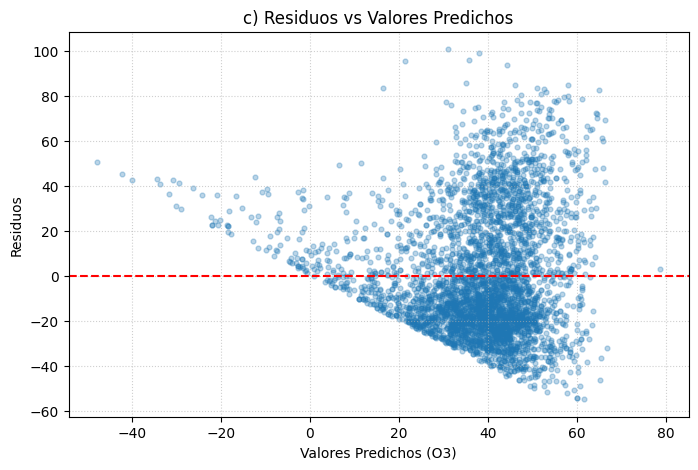

In [67]:
# Gráfica Residuos vs Predichos
plt.figure(figsize=(8, 5))
plt.scatter(predichos, residuos, alpha=0.3, s=12, color="#1f77b4")
plt.axhline(0, color="red", linestyle="--", linewidth=1.5)
plt.title("c) Residuos vs Valores Predichos")
plt.xlabel("Valores Predichos (O3)")
plt.ylabel("Residuos")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

In [68]:
# Prueba de Breusch-Pagan para heterocedasticidad
bp_test = het_breuschpagan(residuos, X_const)
labels = [
    "LM Statistic",
    "LM-Test p-value",
    "F-Statistic",
    "F-Test p-value",
]

print("==================================================")
print("c) PRUEBA DE BREUSCH-PAGAN (Heterocedasticidad)")
print("==================================================")
for label, val in zip(labels, bp_test):
    print(f"{label}: {val:.5e}")

c) PRUEBA DE BREUSCH-PAGAN (Heterocedasticidad)
LM Statistic: 2.23149e+02
LM-Test p-value: 3.93698e-47
F-Statistic: 5.91063e+01
F-Test p-value: 1.63439e-48


d) ESTADÍSTICO DE DURBIN-WATSON: 0.1609


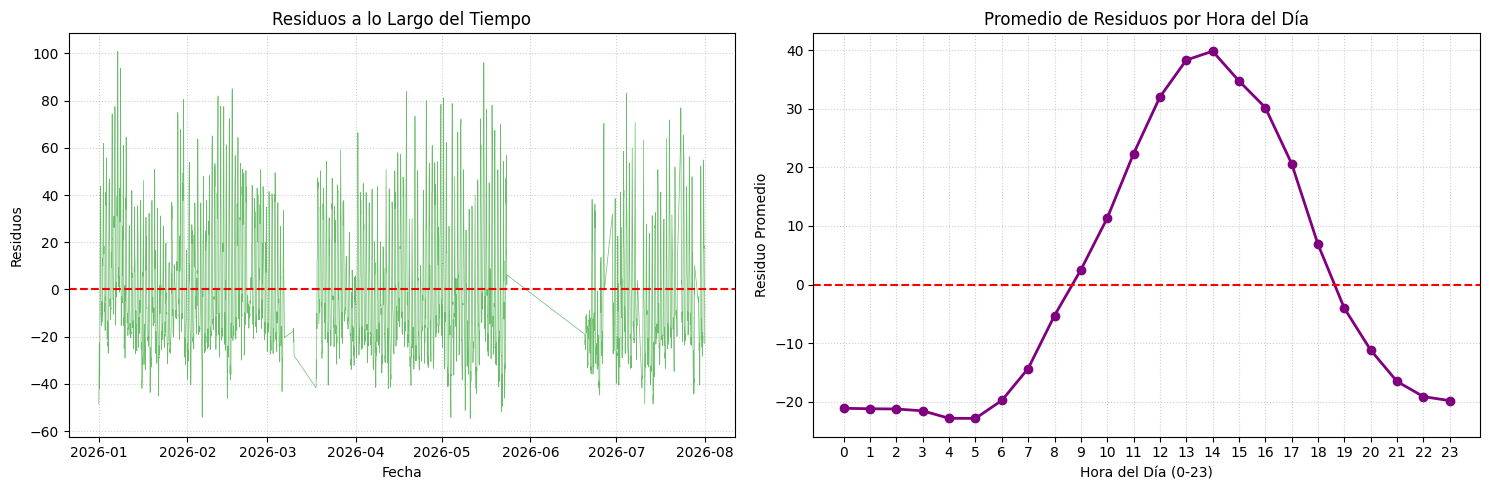

In [69]:
# Estadístico Durbin-Watson
dw_stat = durbin_watson(residuos)
print("==================================================")
print(f"d) ESTADÍSTICO DE DURBIN-WATSON: {dw_stat:.4f}")
print("==================================================")

# Gráficas
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# 1. Residuos en el tiempo
axes[0].plot(pivoted.index, residuos, linewidth=0.5, alpha=0.7, color="#2ca02c")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Residuos a lo Largo del Tiempo")
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("Residuos")
axes[0].grid(True, linestyle=":", alpha=0.6)
# 2. Promedio de residuos por hora del día
res_por_hora = residuos.groupby(pivoted.index.hour).mean()
axes[1].plot(
    res_por_hora.index,
    res_por_hora.values,
    marker="o",
    color="purple",
    linewidth=2,
)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Promedio de Residuos por Hora del Día")
axes[1].set_xlabel("Hora del Día (0-23)")
axes[1].set_ylabel("Residuo Promedio")
axes[1].set_xticks(range(0, 24))
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

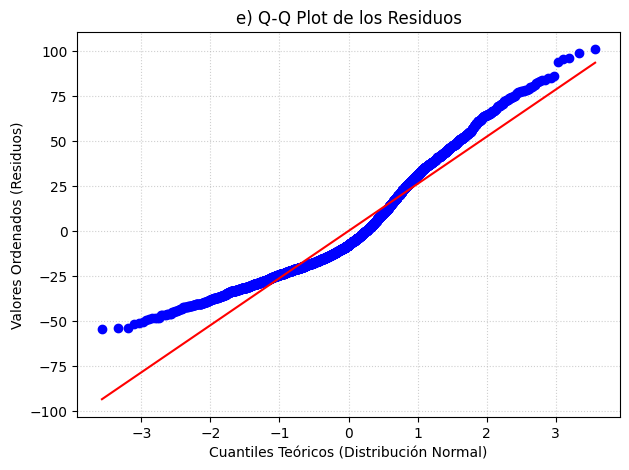

In [70]:
# e) QQ-Plot
plt.figure(figsize=(7, 5))
stats.probplot(residuos, dist="norm", plot=plt)
plt.title("e) Q-Q Plot de los Residuos")
plt.xlabel("Cuantiles Teóricos (Distribución Normal)")
plt.ylabel("Valores Ordenados (Residuos)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

In [71]:
print(f"""
f) ANÁLISIS DE SUPUESTOS Y VALIDEZ DEL NO2 EN ESTACIÓN {estacion} (PEDREGAL):

En la estación Pedregal se violan fuertemente los supuestos clásicos de OLS:
1. No Multicolinealidad: Los VIF de NO (487.3), NO2 (520.5) y NOX (1551.4) son extremadamente altos por la dependencia directa NOX = NO + NO2.
2. Homocedasticidad: El p-value del test de Breusch-Pagan (3.93e-47) es inferior a 0.05, lo que confirma la heterocedasticidad en los errores.
3. Autocorrelación Serial: El estadístico Durbin-Watson de 0.1609 (muy lejano a 2) y la curva cóncava por hora del día indican una clara autocorrelación temporal en la serie de ozono.
4. Normalidad: El Q-Q plot evidencia colas pesadas y desviación respecto a la distribución normal.

¿Se le cree al coeficiente del NO2 y su p-value?
No, no son confiables. La multicolinealidad severa destruye la precisión del estimador del NO2 (con un p-value engañoso de 0.239), inflando su error estándar. Sumado a la autocorrelación serial, las inferencias y pruebas de hipótesis tradicionales de OLS pierden total validez estadística.
""")


f) ANÁLISIS DE SUPUESTOS Y VALIDEZ DEL NO2 EN ESTACIÓN PED (PEDREGAL):

En la estación Pedregal se violan fuertemente los supuestos clásicos de OLS:
1. No Multicolinealidad: Los VIF de NO (487.3), NO2 (520.5) y NOX (1551.4) son extremadamente altos por la dependencia directa NOX = NO + NO2.
2. Homocedasticidad: El p-value del test de Breusch-Pagan (3.93e-47) es inferior a 0.05, lo que confirma la heterocedasticidad en los errores.
3. Autocorrelación Serial: El estadístico Durbin-Watson de 0.1609 (muy lejano a 2) y la curva cóncava por hora del día indican una clara autocorrelación temporal en la serie de ozono.
4. Normalidad: El Q-Q plot evidencia colas pesadas y desviación respecto a la distribución normal.

¿Se le cree al coeficiente del NO2 y su p-value?
No, no son confiables. La multicolinealidad severa destruye la precisión del estimador del NO2 (con un p-value engañoso de 0.239), inflando su error estándar. Sumado a la autocorrelación serial, las inferencias y pruebas de hipótes